
<p align="center">
    <img src="https://github.com/GeostatsGuy/GeostatsPy/blob/master/TCG_color_logo.png?raw=true" width="220" height="240" />

</p>

## Interactive Spatial Data Declustering vs. Naive Demonstration


### Michael Pyrcz, Professor, University of Texas at Austin 

##### [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)


### The Interactive Workflow

Here's an interactive demonstration of the imapct of declustering


### Basic Univariate Summary Statistics and Data Distribution Representativity Plotting in Python with GeostatsPy

Here's a simple workflow with some basic univariate statistics and distribution representativity. This should help you get started data declustering to address spatial sampling bias.

#### Geostatistical Sampling Representativity

In general, we should assume that all spatial data that we work with is biased.

##### Source of Spatial Sampling Bias

Data is collected to answer questions:
* how far does the contaminant plume extend? – sample peripheries
* where is the fault? – drill based on seismic interpretation
* what is the highest mineral grade? – sample the best part
* who far does the reservoir extend? – offset drilling
and to maximize NPV directly:
* maximize production rates

**Random Sampling**: when every item in the population has a equal chance of being chosen. Selection of every item is independent of every other selection.
Is random sampling sufficient for subsurface?  Is it available?
* it is not usually available, would not be economic
* data is collected answer questions
    * how large is the reservoir, what is the thickest part of the reservoir 
* and wells are located to maximize future production
    * dual purpose appraisal and injection / production wells!

**Regular Sampling**: when samples are taken at regular intervals (equally spaced).  
* less reliable than random sampling.
* Warning: may resonate with some unsuspected environmental variable.

What do we have?
* we usually have biased, opportunity sampling 
* we must account for bias (debiasing will be discussed later)

So if we were designing sampling for representativity of the sample set and resulting sample statistics, by theory we have 2 options, random sampling and regular sampling.

* What would happen if you proposed random sampling in the Gulf of Mexico at $150M per well?

We should not change current sampling methods as they result in best economics, we should address sampling bias in the data.

Never use raw spatial data without access sampling bias / correcting.

##### Mitigating Sampling Bias

In this demonstration we will take a biased spatial sample data set and apply declustering using **GeostatsPy** functionality.

#### Objective 

In the PGE 383: Stochastic Subsurface Modeling class I want to provide hands-on experience with building subsurface modeling workflows. Python provides an excellent vehicle to accomplish this. I have coded a package called GeostatsPy with GSLIB: Geostatistical Library (Deutsch and Journel, 1998) functionality that provides basic building blocks for building subsurface modeling workflows. 

The objective is to remove the hurdles of subsurface modeling workflow construction by providing building blocks and sufficient examples. This is not a coding class per se, but we need the ability to 'script' workflows working with numerical methods.    

#### Getting Started

Here's the steps to get setup in Python with the GeostatsPy package:

1. Install Anaconda 3 on your machine (https://www.anaconda.com/download/). 
2. From Anaconda Navigator (within Anaconda3 group), go to the environment tab, click on base (root) green arrow and open a terminal. 
3. In the terminal type: pip install geostatspy. 
4. Open Jupyter and in the top block get started by copy and pasting the code block below from this Jupyter Notebook to start using the geostatspy functionality. 

You will need to copy the data file to your working directory.  They are available here:

* Tabular data - sample_data_biased.csv at https://git.io/fh0CW

There are exampled below with these functions. You can go here to see a list of the available functions, https://git.io/fh4eX, other example workflows and source code. 

In [1]:
import os

os.environ["TQDM_DISABLE"] = "True" 

import geostatspy.GSLIB as GSLIB          # GSLIB utilies, visualization and wrapper
import geostatspy.geostats as geostats    # GSLIB methods convert to Python        

We will also need some standard packages. These should have been installed with Anaconda 3.

In [2]:
import numpy as np                        # ndarrys for gridded data
import pandas as pd                       # DataFrames for tabular data
import os                                 # set working directory, run executables
import matplotlib.pyplot as plt           # for plotting
from scipy import stats                   # summary statistics
from ipywidgets import interactive        # widgets and interactivity
from ipywidgets import widgets                            
from ipywidgets import Layout
from ipywidgets import Label
from ipywidgets import VBox, HBox
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
plt.rc('axes', axisbelow=True)            # set axes and grids in the background for all plots
from matplotlib.patches import Rectangle  # drawing shapes on plots
from statsmodels.stats.weightstats import DescrStatsW
cmap = plt.cm.inferno
burnt_orange = "#BF5700"

If you get a package import error, you may have to first install some of these packages. This can usually be accomplished by opening up a command window on Windows and then typing 'python -m pip install [package-name]'. More assistance is available with the respective package docs.  

#### Declare Functions

These functions read in the multiple realizations and produce local statistical summaries that we will cover below.  They will shortly be added to GeostatsPy.

In [3]:
def add_grid():
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks 

def weighted_percentile(data,perc,weights=None): # from Luca Jokull (https://stackoverflow.com/questions/21844024/weighted-percentile-using-numpy)
    if weights is None:
        return nanpercentile(data,perc)
    else:
        d=data[(~np.isnan(data))&(~np.isnan(weights))]
        ix=np.argsort(d)
        d=d[ix]
        wei=weights[ix]
        wei_cum=100.*np.cumsum(wei*1./sum(wei))
        return np.interp(perc,wei_cum,d)

#### Set the working directory

I always like to do this so I don't lose files and to simplify subsequent read and writes (avoid including the full address each time). 

In [4]:
#os.chdir("c:/PGE383")             # set the working directory

#### Loading Tabular Data

Here's the command to load our comma delimited data file in to a Pandas' DataFrame object.  

In [18]:
df = pd.read_csv('https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/2level_cluster.csv') # load data from Dr. Pyrcz's GitHub 
pormin=4.0; pormax = 16.0
xmin = 0.0; xmax = 10000.0; ymin = 0.0; ymax = 10000
df.head()

,X,Y,Level,Porosity
0,4000.0,4000.0,Coarse,7.812796
1,1000.0,1000.0,Coarse,8.105355
2,5000.0,3000.0,Coarse,9.142711
3,5000.0,4000.0,Coarse,6.589220
4,1000.0,3000.0,Coarse,11.833955


#### Summary Statistics

In [19]:
truth_average = np.average(df.loc[:81,'Porosity'])  # from representative sampling

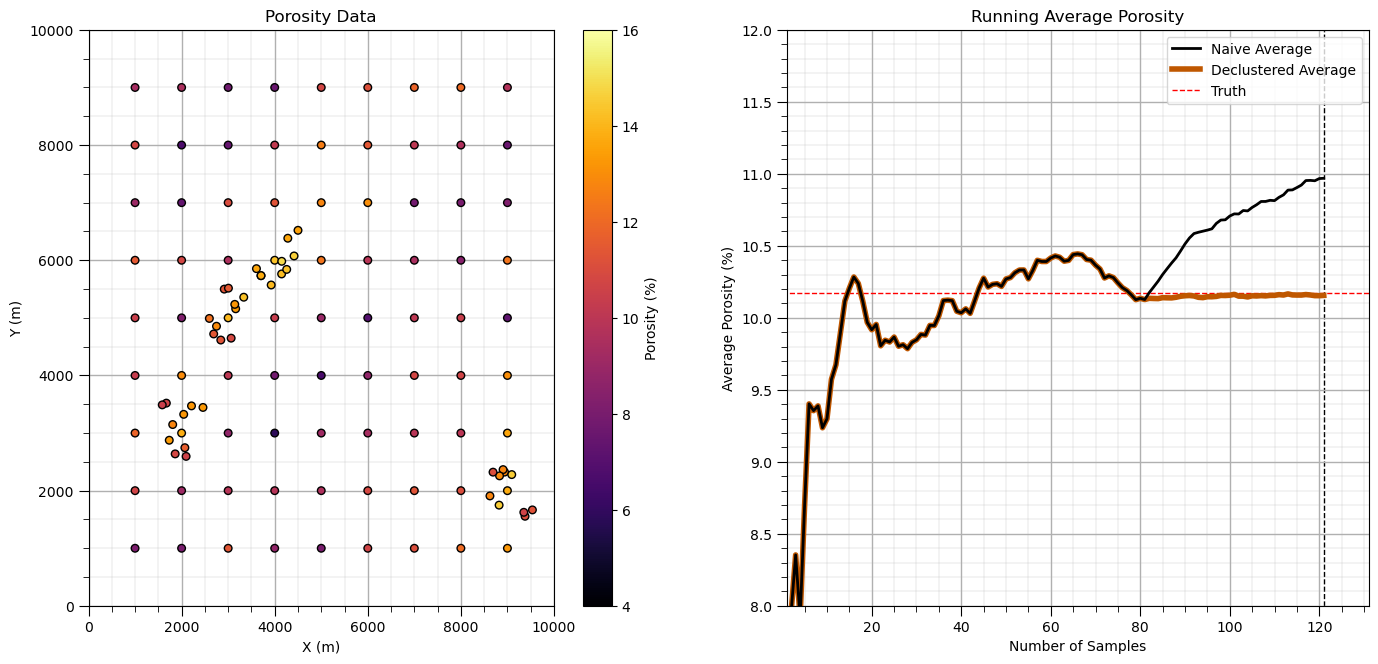

In [20]:
%%capture --no-display       

n_sample = 121; pormin = 4.0; pormax = 16.0
ncell = 1; cmin = 1000; cmax = 1000; noff = 5; iminmax = 1

declus_por_mean = np.zeros(n_sample)

df_subset = df.loc[:n_sample-1,:].copy(deep=True)
por = df_subset["Porosity"].values
cumulative_avg = np.cumsum(por) / np.arange(1, len(por) + 1)
df_subset["Porosity_Cumulative_Mean"] = cumulative_avg

for isample in range(0,n_sample):
    wts, cell_sizes, dmeans = geostats.declus(df_subset.loc[:isample,:],'X','Y','Porosity',iminmax = iminmax,noff = noff,
        ncell = ncell,cmin = cmin,cmax = cmax)                # GeostatsPy's declustering function
    declus_por_mean[isample] = np.average(df_subset.loc[:isample,'Porosity'],weights = wts) 

df_subset["Porosity_Cumulative_Declus_Mean"] = declus_por_mean

plt.subplot(121)
sc = plt.scatter(df_subset['X'],df_subset['Y'],c=df_subset['Porosity'],s=30,edgecolor='black',cmap = cmap, vmin = pormin,vmax = pormax)
cbar = plt.colorbar(sc)
cbar.set_label("Porosity (%)")

add_grid(); plt.xlim([xmin,xmax]); plt.ylim([ymin,ymax])
plt.xlabel('X (m)'); plt.ylabel('Y (m)'); plt.title('Porosity Data')


plt.subplot(122)
plt.plot(np.arange(0,n_sample)+1,df_subset["Porosity_Cumulative_Mean"],c='black',lw=2,label='Naive Average',zorder=3)
plt.plot(np.arange(0,n_sample)+1,df_subset["Porosity_Cumulative_Declus_Mean"],c=burnt_orange,lw=4,label='Declustered Average',zorder=2)
plt.plot([0,len(df)],[truth_average,truth_average],c='red',lw=1,ls='--',label='Truth',zorder=1)
plt.axvline(x=len(df_subset), linestyle="--", color="black", linewidth=1, zorder=0)
plt.legend(loc='upper right')
plt.xlim([1,len(df)]); plt.ylim([8.0,12.0]); plt.xlabel('Number of Samples'); plt.ylabel('Average Porosity (%)'); plt.title('Running Average Porosity')
add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.2, wspace=0.2, hspace=0.2); plt.show()

#### Interactive Dashboard

In [21]:
%%capture --no-display

from tqdm.auto import tqdm
import sys
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

pormin = 4.0; pormax = 16.0
ncell = 1; cmin = 1000; cmax = 1000; noff = 5; iminmax = 1

# interactive calculation of the sample set (control of source parametric distribution and number of samples)
style = {'description_width': 'initial'}
l = widgets.Text(value='                                              Cell-based Declustering, Michael Pyrcz, Associate Professor, The University of Texas at Austin',layout=Layout(width='950px', height='30px'))
nsample = widgets.IntSlider(min = 1, max = len(df), value = 5, step = 10, description = 'Cell Size',style=style,orientation='horizontal',
                          layout=Layout(width='450px', height='50px'),continuous_update = False)
nsample.style.handle_color = 'gray'

ui = widgets.VBox([l,nsample],)

def f_make_declus(nsample):

    declus_por_mean = np.zeros(nsample)
    df_subset = df.loc[:nsample-1,:].copy(deep=True)
    por = df_subset["Porosity"].values
    cumulative_avg = np.cumsum(por) / np.arange(1, len(por) + 1)
    df_subset["Porosity_Cumulative_Mean"] = cumulative_avg
    #for isample in range(0, nsample):
    for isample in tqdm(range(nsample), disable=True):
        with suppress_stdout():
            wts, cell_sizes, dmeans = geostats.declus(
                df_subset.loc[:isample,:],
                'X','Y','Porosity',
                iminmax=iminmax,
                noff=noff,
                ncell=ncell,
                cmin=cmin,
                cmax=cmax
            )
            declus_por_mean[isample] = np.average(
                df_subset.loc[:isample,'Porosity'],
                weights=wts
            )
        df_subset["Porosity_Cumulative_Declus_Mean"] = declus_por_mean


    
    # declus_por_mean = np.zeros(nsample)
    
    # df_subset = df.loc[:nsample-1,:].copy(deep=True)
    # por = df_subset["Porosity"].values
    # cumulative_avg = np.cumsum(por) / np.arange(1, len(por) + 1)
    # df_subset["Porosity_Cumulative_Mean"] = cumulative_avg
    
    # for isample in range(0,nsample):
    #     wts, cell_sizes, dmeans = geostats.declus(df_subset.loc[:isample,:],'X','Y','Porosity',iminmax = iminmax,noff = noff,
    #         ncell = ncell,cmin = cmin,cmax = cmax)                # GeostatsPy's declustering function
    #     declus_por_mean[isample] = np.average(df_subset.loc[:isample,'Porosity'],weights = wts) 
    
    # df_subset["Porosity_Cumulative_Declus_Mean"] = declus_por_mean
    
    plt.subplot(121)
    sc = plt.scatter(df_subset['X'],df_subset['Y'],c=df_subset['Porosity'],s=30,edgecolor='black',cmap = cmap, vmin = pormin,vmax = pormax)
    cbar = plt.colorbar(sc)
    cbar.set_label("Porosity (%)")
    
    add_grid(); plt.xlim([xmin,xmax]); plt.ylim([ymin,ymax])
    plt.xlabel('X (m)'); plt.ylabel('Y (m)'); plt.title('Porosity Data')
    
    
    plt.subplot(122)
    plt.plot(np.arange(0,nsample)+1,df_subset["Porosity_Cumulative_Mean"],c='black',lw=2,label='Naive Average',zorder=3)
    plt.plot(np.arange(0,nsample)+1,df_subset["Porosity_Cumulative_Declus_Mean"],c=burnt_orange,lw=4,label='Declustered Average',zorder=2)
    plt.plot([0,len(df)],[truth_average,truth_average],c='red',lw=1,ls='--',label='Truth',zorder=1)
    plt.axvline(x=len(df_subset), linestyle="--", color="black", linewidth=1, zorder=0)
    plt.legend(loc='upper right')
    plt.xlim([1,len(df)]); plt.ylim([8.0,12.0]); plt.xlabel('Number of Samples'); plt.ylabel('Average Porosity (%)'); plt.title('Running Average Porosity')
    add_grid()
    
    plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.2, wspace=0.2, hspace=0.2); plt.show()
    
# connect the function to make the samples and plot to the widgets    
interactive_plot = widgets.interactive_output(f_make_declus, {'nsample':nsample})
interactive_plot.clear_output(wait = True)               # reduce flickering by delaying plot updating


### Interactive Cell-based Declustering Demostration

* select the cell size and number of cell mesh offsets and visualize the declustering method 

#### Michael Pyrcz, Associate Professor, University of Texas at Austin 

##### [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1) | [GeostatsPy](https://github.com/GeostatsGuy/GeostatsPy)

### The Inputs

* **Cell Size**: the size the of the cells in the mesh, **Number of Offsets**: number of cell mesh offsets to average to calculate the data weights 

In [22]:
display(ui, interactive_plot)                            # display the interactive plot

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 640x480 with 3 Axes>', 'i…

In [31]:
%%capture --no-display

from tqdm.auto import tqdm
import sys
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

pormin = 4.0; pormax = 16.0
ncell = 1; cmin = 1000; cmax = 1000; noff = 5; iminmax = 1

# interactive calculation of the sample set (control of source parametric distribution and number of samples)
style = {'description_width': 'initial'}
l = widgets.Text(value='                                              Comparison Cell-based Declustered vs. Naïve Statistics, Michael Pyrcz, Professor, The University of Texas at Austin',layout=Layout(width='950px', height='30px'))
nsample = widgets.BoundedIntText(min = 1, max = len(df), value = 1, step = 3, description = 'Number of Samples',style=style,orientation='horizontal',
                          layout=Layout(width='450px', height='50px'),continuous_update = False)
nsample.style.handle_color = 'gray'

ui = widgets.VBox([l,nsample],)

def f_make_declus(nsample):


    
    declus_por_mean = np.zeros(nsample)
    df_subset = df.loc[:nsample-1,:].copy(deep=True)
    por = df_subset["Porosity"].values
    cumulative_avg = np.cumsum(por) / np.arange(1, len(por) + 1)
    df_subset["Porosity_Cumulative_Mean"] = cumulative_avg
    #for isample in range(0, nsample):
    for isample in tqdm(range(nsample), disable=True):
        with suppress_stdout():
            wts, cell_sizes, dmeans = geostats.declus(
                df_subset.loc[:isample,:],
                'X','Y','Porosity',
                iminmax=iminmax,
                noff=noff,
                ncell=ncell,
                cmin=cmin,
                cmax=cmax
            )
            declus_por_mean[isample] = np.average(
                df_subset.loc[:isample,'Porosity'],
                weights=wts
            )
        df_subset["Porosity_Cumulative_Declus_Mean"] = declus_por_mean

    with out:
        out.clear_output(wait=True)
            
        plt.subplot(121)
        sc = plt.scatter(df_subset['X'],df_subset['Y'],c=df_subset['Porosity'],s=30,edgecolor='black',cmap = cmap, vmin = pormin,vmax = pormax)
        cbar = plt.colorbar(sc)
        cbar.set_label("Porosity (%)")
        
        add_grid(); plt.xlim([xmin,xmax]); plt.ylim([ymin,ymax])
        plt.xlabel('X (m)'); plt.ylabel('Y (m)'); plt.title('Porosity Data')
        
        plt.subplot(122)
        plt.plot(np.arange(0,nsample)+1,df_subset["Porosity_Cumulative_Mean"],c='black',lw=2,label='Naive Average',zorder=3)
        plt.plot(np.arange(0,nsample)+1,df_subset["Porosity_Cumulative_Declus_Mean"],c=burnt_orange,lw=4,label='Declustered Average',zorder=2)
        plt.plot([0,len(df)],[truth_average,truth_average],c='red',lw=1,ls='--',label='Truth',zorder=1)
        plt.axvline(x=len(df_subset), linestyle="--", color="black", linewidth=1, zorder=0)
        plt.legend(loc='upper right')
        plt.xlim([1,len(df)]); plt.ylim([7.0,12.0]); plt.xlabel('Number of Samples'); plt.ylabel('Average Porosity (%)'); plt.title('Running Average Porosity')
        add_grid()
        
        plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.2, wspace=0.15, hspace=0.2); plt.show()
        plt.figure(figsize=(12,5))


out = widgets.Output(layout=widgets.Layout(height='650px'))  # fixed height

interactive_plot = widgets.interactive_output(
    f_make_declus,
    {'nsample': nsample}
)

display(ui, out)

Output(layout=Layout(height='650px'))

#### Comments

This is an interactive demonstration of cell-based declustering to correct for sampling bias. Much more could be done, I have other demonstrations on the basics of working with DataFrames, ndarrays and many other workflows availble at https://github.com/GeostatsGuy/PythonNumericalDemos and https://github.com/GeostatsGuy/GeostatsPy.

I hope this was helpful,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Associate Professor The Hildebrand Department of Petroleum and Geosystems Engineering, Bureau of Economic Geology, The Jackson School of Geosciences, The University of Texas at Austin

#### More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)
